# Tour Package Pricing & Recommendation Engine
### Step-by-step: data processing → feature engineering → model training

This notebook builds the two core models behind the pricing + recommendation
engine described in the case study:

1. **Demand-adjusted pricing model** — an `XGBoost` regressor trained on
   booking lead time, seasonality, destination popularity, and group size to
   predict what a package *should* cost, replacing a static rate card.
2. **Hybrid recommendation engine** — content-based filtering (package
   attributes) blended with collaborative filtering (user rating patterns) to
   surface personalized package suggestions.

**Data:** `packages.csv`, `bookings.csv`, `users.csv`, `ratings.csv`
(all in the same folder as this notebook).



## 0. Setup & imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

import xgboost as xgb
import joblib
import os

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (8, 4)

RANDOM_STATE = 42
os.makedirs("models", exist_ok=True)


## 1. Load the data

Four linked tables:
- **packages** — the catalog (destination, duration, base rate-card price, category, season, popularity)
- **bookings** — transactions (what was actually paid, lead time, group size) — this is our pricing signal
- **users** — profiles (preferred categories, budget range)
- **ratings** — explicit user → package ratings — this drives collaborative filtering


In [2]:
packages = pd.read_csv("packages.csv")
bookings = pd.read_csv("bookings.csv", parse_dates=["booking_date", "travel_date"])
users = pd.read_csv("users.csv", parse_dates=["signup_date"])
ratings = pd.read_csv("ratings.csv", parse_dates=["rating_date"])

print("packages:", packages.shape)
print("bookings:", bookings.shape)
print("users:   ", users.shape)
print("ratings: ", ratings.shape)

packages.head()


packages: (60, 9)
bookings: (4000, 8)
users:    (400, 5)
ratings:  (2500, 4)


,package_id,destination,duration_days,base_price,category,season_tag,group_size_range,is_international,destination_popularity
0,PKG0001,Bali (Intl),6,46100,Honeymoon,All-Season,4-6,True,0.903
1,PKG0002,Andaman Islands,2,8400,Beach,All-Season,1-2,False,0.596
2,PKG0003,Thailand (Intl),12,123800,Beach,Summer,10+,True,0.592
3,PKG0004,Hampi,4,9100,Cultural,Summer,2-4,False,0.335
4,PKG0005,Andaman Islands,7,22200,Beach,Summer,10+,False,0.596


In [3]:
bookings.head()


,booking_id,package_id,user_id,booking_date,travel_date,lead_time_days,group_size,final_price_paid
0,BKG00001,PKG0014,USR0348,2025-01-14,2025-02-28,45,2,12280
1,BKG00002,PKG0048,USR0191,2024-03-19,2024-04-03,15,5,52240
2,BKG00003,PKG0038,USR0294,2025-01-10,2025-01-25,15,2,201940
3,BKG00004,PKG0004,USR0204,2024-10-12,2024-10-22,10,2,19300
4,BKG00005,PKG0026,USR0128,2024-01-27,2024-02-16,20,4,109770


In [4]:
users.head()


,user_id,preferred_categories,budget_range,past_bookings_count,signup_date
0,USR0001,Wildlife,10k-25k,2,2023-10-13
1,USR0002,Leisure;Adventure,50k-100k,3,2025-04-07
2,USR0003,Adventure;Honeymoon;Beach,<10k,3,2023-04-06
3,USR0004,Leisure,50k-100k,3,2024-05-12
4,USR0005,Leisure;Wildlife,<10k,2,2023-06-18


In [5]:
ratings.head()


,user_id,package_id,rating,rating_date
0,USR0297,PKG0024,4,2024-05-16
1,USR0245,PKG0006,5,2024-07-18
2,USR0217,PKG0023,5,2025-03-04
3,USR0317,PKG0013,4,2025-08-05
4,USR0090,PKG0028,5,2024-07-17


## 2. Data quality checks

Quick sanity pass before we build anything: nulls, dtypes, duplicates, and
whether every `package_id` / `user_id` referenced in bookings/ratings
actually exists in the catalog.


In [6]:
for name, df in [("packages", packages), ("bookings", bookings),
                  ("users", users), ("ratings", ratings)]:
    print(f"--- {name} ---")
    print(df.dtypes)
    print("nulls:\n", df.isnull().sum()[df.isnull().sum() > 0])
    print("duplicate rows:", df.duplicated().sum())
    print()


--- packages ---
package_id                    str
destination                   str
duration_days               int64
base_price                  int64
category                      str
season_tag                    str
group_size_range              str
is_international             bool
destination_popularity    float64
dtype: object
nulls:
 Series([], dtype: int64)
duplicate rows: 0

--- bookings ---
booking_id                     str
package_id                     str
user_id                        str
booking_date        datetime64[us]
travel_date         datetime64[us]
lead_time_days               int64
group_size                   int64
final_price_paid             int64
dtype: object
nulls:
 Series([], dtype: int64)
duplicate rows: 0

--- users ---
user_id                            str
preferred_categories               str
budget_range                       str
past_bookings_count              int64
signup_date             datetime64[us]
dtype: object
nulls:
 Series([], dtype:

## 3. Exploratory data analysis

We expect (and want to confirm) the demand signals the model should learn:
- Price rises as **lead time shrinks** (last-minute urgency premium)
- **Peak-season** travel months carry a price premium
- More **popular destinations** command a premium


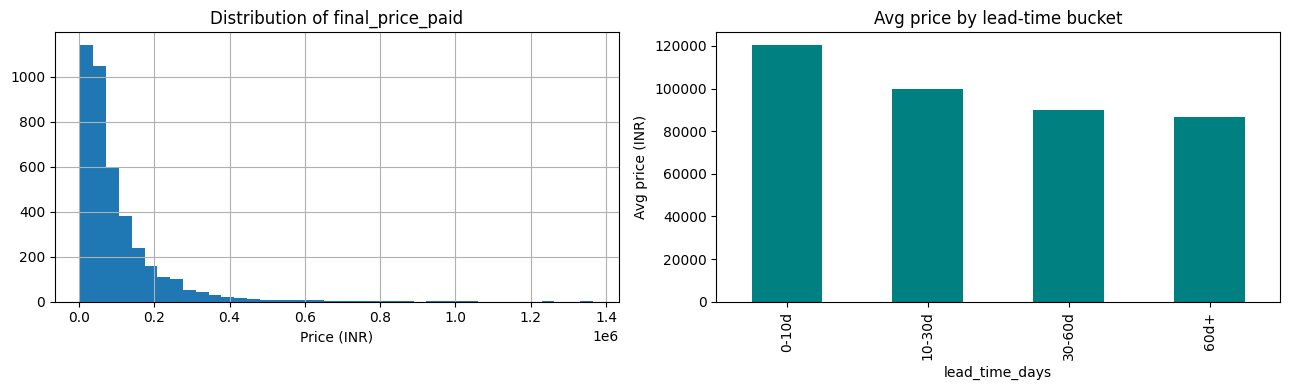

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

bookings["final_price_paid"].hist(bins=40, ax=axes[0])
axes[0].set_title("Distribution of final_price_paid")
axes[0].set_xlabel("Price (INR)")

lead_bucket = pd.cut(bookings["lead_time_days"], [0, 10, 30, 60, 200],
                      labels=["0-10d", "10-30d", "30-60d", "60d+"])
bookings.groupby(lead_bucket, observed=True)["final_price_paid"].mean().plot(
    kind="bar", ax=axes[1], color="teal"
)
axes[1].set_title("Avg price by lead-time bucket")
axes[1].set_ylabel("Avg price (INR)")

plt.tight_layout()
plt.show()


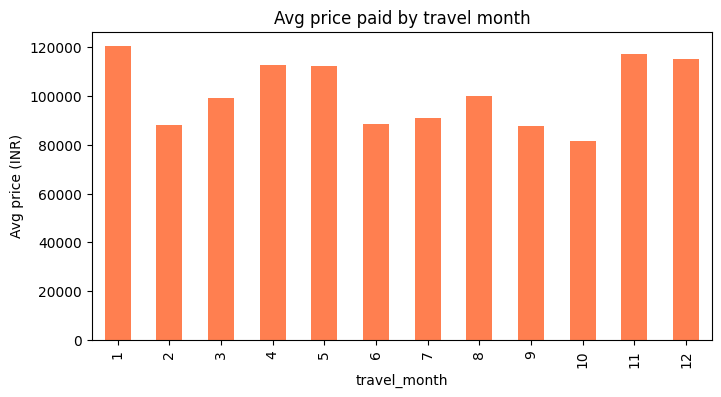

In [9]:
# seasonality check: merge travel month back in and look at price by month
bookings["travel_month"] = bookings["travel_date"].dt.month
bookings.groupby("travel_month")["final_price_paid"].mean().plot(
    kind="bar", color="coral", title="Avg price paid by travel month"
)
plt.ylabel("Avg price (INR)")
plt.show()


## 4. Feature engineering (pricing model)

Join bookings → packages so every booking row carries the catalog attributes
(base rate-card price, popularity, category, season, duration), then engineer
the demand signals:

| Feature | Why it matters |
|---|---|
| `lead_time_days` | last-minute bookings cost more (urgency premium) |
| `is_peak_month` | Nov/Dec/Jan/Apr/May = Indian holiday + wedding + summer peak |
| `destination_popularity` | hot destinations command a premium |
| `group_size` | larger groups get a small per-head volume discount |
| `duration_days`, `base_price` | the catalog "sticker price" baseline |
| `category`, `season_tag`, `is_international` | one-hot encoded categoricals |

**Target:** `final_price_paid` — what the customer actually paid, i.e. the
demand-adjusted price the model should learn to reproduce.


In [10]:
data = bookings.merge(packages, on="package_id", how="left", validate="many_to_one")

PEAK_MONTHS = {11, 12, 1, 4, 5}
data["is_peak_month"] = data["travel_month"].isin(PEAK_MONTHS).astype(int)

# lead-time bucket kept as a *categorical* alongside the raw numeric value —
# gives the tree model an easy split point while still allowing it to find
# its own thresholds on the continuous feature
data["lead_time_bucket"] = pd.cut(
    data["lead_time_days"], [0, 5, 15, 45, 90, 1000],
    labels=["0-5", "6-15", "16-45", "46-90", "90+"]
)

numeric_features = [
    "lead_time_days", "duration_days", "base_price",
    "destination_popularity", "group_size", "is_peak_month",
]
categorical_features = [
    "category", "season_tag", "is_international", "lead_time_bucket",
]
target = "final_price_paid"

model_df = data[numeric_features + categorical_features + [target]].dropna()
print(model_df.shape)
model_df.head()


(4000, 11)


,lead_time_days,duration_days,base_price,destination_popularity,group_size,is_peak_month,category,season_tag,is_international,lead_time_bucket,final_price_paid
0,45,2,5800,0.898,2,0,Beach,Monsoon,False,16-45,12280
1,15,3,8700,0.323,5,1,Wildlife,Summer,False,6-15,52240
2,15,10,74900,0.610,2,1,Cultural,Off-Season,True,6-15,201940
3,10,4,9100,0.335,2,0,Cultural,Summer,False,6-15,19300
4,20,10,32500,0.312,4,0,Leisure,Monsoon,False,16-45,109770


## 5. Train / test split & preprocessing pipeline

One-hot encode the categoricals, leave the numerics as-is (trees don't need
scaling), and wrap it all in an `sklearn` `ColumnTransformer` so preprocessing
+ model travel together as a single artifact.


In [11]:
X = model_df[numeric_features + categorical_features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

print("train:", X_train.shape, " test:", X_test.shape)


train: (3200, 10)  test: (800, 10)


## 6. Train the XGBoost pricing model


In [12]:
xgb_model = xgb.XGBRegressor(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

pricing_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_model),
])

pricing_pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

### Evaluation

In [13]:
preds = pricing_pipeline.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100

print(f"MAE:  INR {mae:,.0f}")
print(f"RMSE: INR {rmse:,.0f}")
print(f"MAPE: {mape:.1f}%")
print(f"R^2:  {r2:.3f}")


MAE:  INR 6,371
RMSE: INR 15,806
MAPE: 6.1%
R^2:  0.979


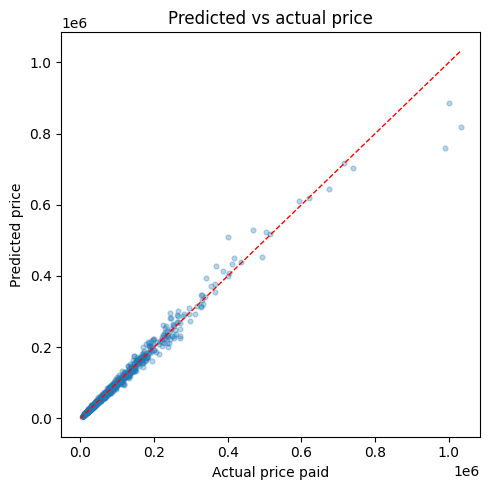

In [14]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(y_test, preds, alpha=0.3, s=12)
lims = [0, max(y_test.max(), preds.max())]
ax.plot(lims, lims, "r--", linewidth=1)
ax.set_xlabel("Actual price paid")
ax.set_ylabel("Predicted price")
ax.set_title("Predicted vs actual price")
plt.tight_layout()
plt.show()


### Feature importance

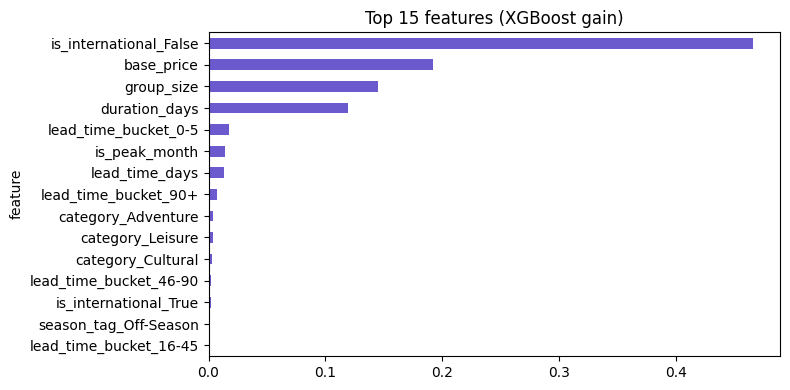

In [15]:
feature_names = (
    numeric_features
    + list(pricing_pipeline.named_steps["preprocess"]
           .named_transformers_["cat"].get_feature_names_out(categorical_features))
)
importances = pricing_pipeline.named_steps["model"].feature_importances_

imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False).head(15)

imp_df.plot(kind="barh", x="feature", y="importance", legend=False,
            color="slateblue", title="Top 15 features (XGBoost gain)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 7. Wrap it as a demand-adjusted pricing function

This is the function a Streamlit app would call: given a package + trip
details, return the model's demand-adjusted price (vs. the static
`base_price` on the rate card).


In [16]:
def predict_price(package_id, travel_date, group_size, booking_date=None):
    """Return (base_price, model_predicted_price) for a hypothetical booking."""
    booking_date = pd.Timestamp(booking_date or pd.Timestamp.today().normalize())
    travel_date = pd.Timestamp(travel_date)
    lead_time_days = (travel_date - booking_date).days

    pkg = packages.loc[packages["package_id"] == package_id].iloc[0]
    month = travel_date.month
    is_peak_month = int(month in PEAK_MONTHS)
    lead_bucket = pd.cut([lead_time_days], [0, 5, 15, 45, 90, 1000],
                          labels=["0-5", "6-15", "16-45", "46-90", "90+"])[0]

    row = pd.DataFrame([{
        "lead_time_days": lead_time_days,
        "duration_days": pkg["duration_days"],
        "base_price": pkg["base_price"],
        "destination_popularity": pkg["destination_popularity"],
        "group_size": group_size,
        "is_peak_month": is_peak_month,
        "category": pkg["category"],
        "season_tag": pkg["season_tag"],
        "is_international": pkg["is_international"],
        "lead_time_bucket": lead_bucket,
    }])

    predicted = pricing_pipeline.predict(row)[0]
    return pkg["base_price"], float(predicted)


# quick demo: same package, last-minute vs. far-out booking
base, last_minute = predict_price("PKG0001", travel_date="2026-01-10",
                                   group_size=2, booking_date="2026-01-05")
_, early_bird = predict_price("PKG0001", travel_date="2026-06-10",
                               group_size=2, booking_date="2026-01-05")

print(f"Rate-card base price:      INR {base:,.0f}")
print(f"Predicted (5-day lead):    INR {last_minute:,.0f}")
print(f"Predicted (early booking): INR {early_bird:,.0f}")


Rate-card base price:      INR 46,100
Predicted (5-day lead):    INR 140,880
Predicted (early booking): INR 80,999


## 8. Recommendation engine — content-based filtering

Build a text "profile" per package from its attributes (category,
destination, season, international flag), TF-IDF vectorize it, and compute
pairwise cosine similarity. This lets us recommend packages similar to one
the user already booked/rated highly — works even for brand-new packages
with no rating history yet ("cold start").


In [17]:
packages_cb = packages.copy()

def duration_bucket(d):
    if d <= 3: return "short-trip"
    if d <= 7: return "week-trip"
    return "long-trip"

packages_cb["duration_tag"] = packages_cb["duration_days"].apply(duration_bucket)
packages_cb["intl_tag"] = np.where(packages_cb["is_international"], "international", "domestic")

packages_cb["profile"] = (
    packages_cb["category"] + " " +
    packages_cb["destination"].str.replace(r"\s*\(Intl\)", "", regex=True) + " " +
    packages_cb["season_tag"] + " " +
    packages_cb["duration_tag"] + " " +
    packages_cb["intl_tag"]
)

packages_cb[["package_id", "profile"]].head()


,package_id,profile
0,PKG0001,Honeymoon Bali All-Season week-trip international
1,PKG0002,Beach Andaman Islands All-Season short-trip do...
2,PKG0003,Beach Thailand Summer long-trip international
3,PKG0004,Cultural Hampi Summer week-trip domestic
4,PKG0005,Beach Andaman Islands Summer week-trip domestic


In [18]:
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(packages_cb["profile"])

content_sim = cosine_similarity(tfidf_matrix)
content_sim_df = pd.DataFrame(
    content_sim, index=packages_cb["package_id"], columns=packages_cb["package_id"]
)

def similar_packages(package_id, top_n=5):
    scores = content_sim_df[package_id].drop(index=package_id).sort_values(ascending=False)
    top = scores.head(top_n).index
    return packages_cb.set_index("package_id").loc[top, ["destination", "category", "season_tag", "base_price"]]

similar_packages("PKG0001")


,destination,category,season_tag,base_price
package_id,,,,
PKG0020,Bali (Intl),Honeymoon,All-Season,24500
PKG0030,Maldives (Intl),Honeymoon,All-Season,93100
PKG0058,Thailand (Intl),Beach,All-Season,25400
PKG0047,Vietnam (Intl),Cultural,All-Season,27300
PKG0034,Thailand (Intl),Honeymoon,Winter,41800


In [20]:
def cf_recommend(user_id, top_n=5):
    already_rated = rating_matrix.loc[user_id]
    scores = cf_pred.loc[user_id].where(already_rated == 0).dropna()
    top = scores.sort_values(ascending=False).head(top_n).index
    return packages.set_index("package_id").loc[top, ["destination", "category", "season_tag", "base_price"]]

cf_recommend(rating_matrix.index[0])


,destination,category,season_tag,base_price
package_id,,,,
PKG0044,Dubai (Intl),Leisure,All-Season,58600
PKG0054,Ladakh,Adventure,All-Season,19500
PKG0023,Bhutan (Intl),Cultural,Winter,69700
PKG0008,Dubai (Intl),Pilgrimage,Peak-Winter,39300
PKG0028,Kashmir,Honeymoon,Winter,12800


## 10. Hybrid recommendations

Blend the two signals into one ranked list:
- **Collaborative score** — predicted rating from the SVD reconstruction (captures "users like you also liked...")
- **Content score** — average similarity to packages the user has already rated highly (captures "more of what you liked", robust for new/under-rated packages)

Both are min-max normalized to `[0, 1]` before blending so neither scale
dominates.


In [21]:
def _minmax(s):
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())

def hybrid_recommend(user_id, top_n=5, alpha=0.6):
    """alpha weights collaborative vs. content score (alpha=1 -> pure CF)."""
    rated = rating_matrix.loc[user_id]
    liked = rated[rated >= 4].index.tolist()  # packages this user rated highly

    # collaborative score for every unrated package
    cf_scores = cf_pred.loc[user_id].where(rated == 0).dropna()

    # content score: avg similarity to the user's liked packages
    if liked:
        content_scores = content_sim_df.loc[liked, cf_scores.index].mean(axis=0)
    else:
        content_scores = pd.Series(0, index=cf_scores.index)

    blended = alpha * _minmax(cf_scores) + (1 - alpha) * _minmax(content_scores)
    top = blended.sort_values(ascending=False).head(top_n).index
    return packages.set_index("package_id").loc[top, ["destination", "category", "season_tag", "base_price"]]

sample_user = rating_matrix.index[0]
print("Recommendations for", sample_user)
hybrid_recommend(sample_user)


Recommendations for USR0001


,destination,category,season_tag,base_price
package_id,,,,
PKG0054,Ladakh,Adventure,All-Season,19500
PKG0031,Sri Lanka (Intl),Wildlife,Off-Season,31200
PKG0045,Munnar,Leisure,Off-Season,32400
PKG0050,Munnar,Leisure,Monsoon,6400
PKG0025,Ladakh,Adventure,Peak-Winter,10500


## 11. Save artifacts

Persist everything a Streamlit app needs so it can serve predictions
instantly without retraining:
- `pricing_model.pkl` — full sklearn pipeline (preprocessing + XGBoost)
- `content_similarity.pkl` — package × package cosine similarity matrix
- `cf_predictions.pkl` — reconstructed user × package rating matrix
- `rating_matrix.pkl` — the raw (sparse) ratings matrix, needed to know what's already rated


In [22]:
joblib.dump(pricing_pipeline, "models/pricing_model.pkl")
joblib.dump(content_sim_df, "models/content_similarity.pkl")
joblib.dump(cf_pred, "models/cf_predictions.pkl")
joblib.dump(rating_matrix, "models/rating_matrix.pkl")

print("Saved to ./models/:")
for f in sorted(os.listdir("models")):
    print(" -", f)


Saved to ./models/:
 - cf_predictions.pkl
 - content_similarity.pkl
 - pricing_model.pkl
 - rating_matrix.pkl


## Next steps

- Wrap `predict_price()` and `hybrid_recommend()` behind a Streamlit UI:
  a package/date/group-size selector calling the pricing model, and a
  user picker showing their top-5 hybrid recommendations.
- Retrain periodically as new `bookings.csv` / `ratings.csv` rows land —
  the pipeline above is a single `fit()` call away from a scheduled job.
- For production-scale collaborative filtering, swap `TruncatedSVD` for
  `implicit`/`surprise`'s SVD++ or a neural matrix-factorization model once
  the ratings volume grows well beyond this synthetic set.
